In [4]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("WARNING: CUDA not detected. Training will be slow on CPU.")

PyTorch version: 2.13.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA version: 12.6


In [1]:
from torchvision import datasets, transforms

# Convert raw images to PyTorch tensors
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download EuroSAT dataset (first run downloads ~90MB)
dataset = datasets.EuroSAT(root="data", download=True, transform=transform)

# Print dataset statistics
class_names = dataset.classes
print(f"Dataset size: {len(dataset)} images")
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

# Inspect a single image tensor
image, label = dataset[0]
print(f"\nImage shape: {image.shape}")
print(f"Label: {label} ({class_names[label]})")

100.0%


Dataset size: 27000 images
Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Image shape: torch.Size([3, 64, 64])
Label: 0 (AnnualCrop)


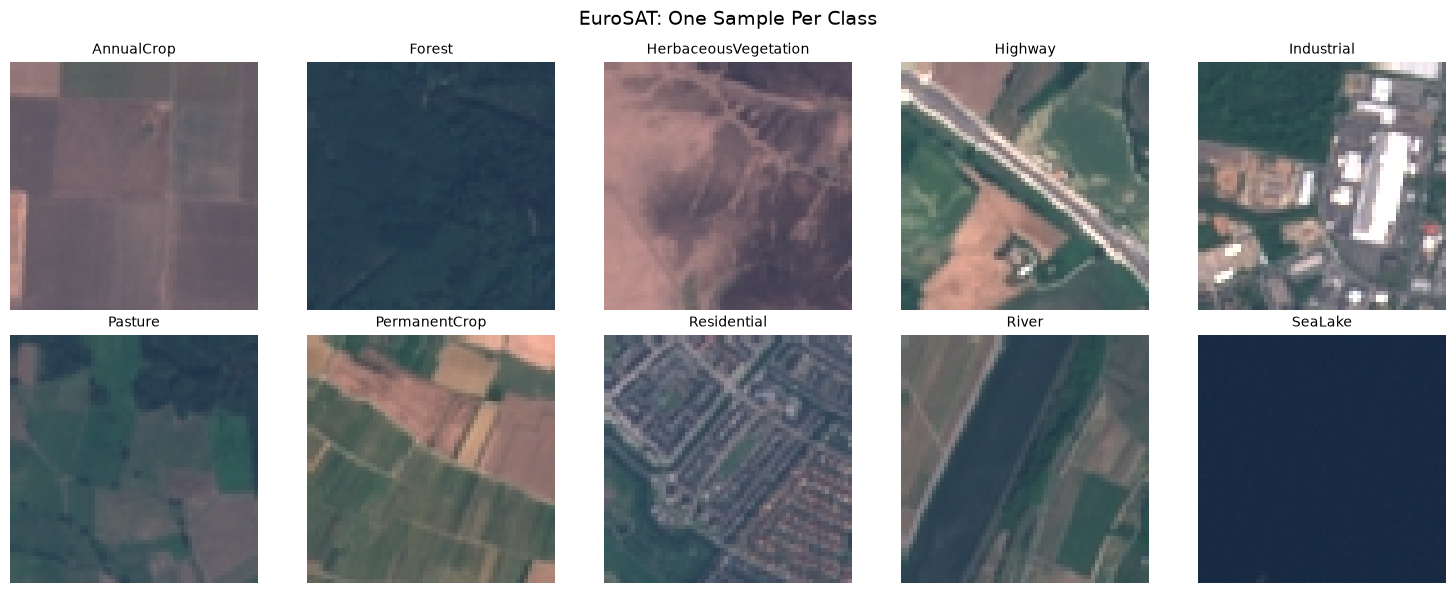

Saved visualization to eurosat_samples.png


In [2]:
import matplotlib.pyplot as plt

# Create a 2x5 grid for displaying samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Find the first example of each class
class_examples = {}
for i in range(len(dataset)):
    _, label = dataset[i]
    if label not in class_examples:
        class_examples[label] = i
    if len(class_examples) == 10:
        break

# Plot each class example
for idx, (label, sample_idx) in enumerate(sorted(class_examples.items())):
    image, _ = dataset[sample_idx]
    axes[idx].imshow(image.permute(1, 2, 0))
    axes[idx].set_title(class_names[label], fontsize=10)
    axes[idx].axis("off")

plt.suptitle("EuroSAT: One Sample Per Class", fontsize=14)
plt.tight_layout()
plt.savefig("eurosat_samples.png")
plt.show()
print("Saved visualization to eurosat_samples.png")

In [5]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Data Loading ---
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Reload dataset with normalization
dataset_normalized = datasets.EuroSAT(root="data", download=True, transform=transform_train)
class_names = dataset_normalized.classes

# Split into train/test (80/20)
generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(dataset_normalized))
test_size = len(dataset_normalized) - train_size
train_dataset, test_dataset = random_split(
    dataset_normalized, [train_size, test_size], generator=generator
)

print(f"Training samples: {train_size}")
print(f"Test samples: {test_size}")

Training samples: 21600
Test samples: 5400


In [6]:
# Set up device and DataLoaders
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

Using device: cuda


In [7]:
# --- Model Definition ---
class SatelliteCNN(nn.Module):
    def __init__(self):
        super(SatelliteCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [8]:
# Create model and test forward pass
model = SatelliteCNN().to(device)
print(f"Model architecture:\n{model}")

# Verify dimensions with a dummy batch
dummy = torch.randn(64, 3, 64, 64).to(device)
output = model(dummy)
print(f"\nTest forward pass output shape: {output.shape}")

Model architecture:
SatelliteCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Test forward pass output shape: torch.Size([64, 10])


In [9]:
# --- Training Function ---
def train_model(model, train_loader, criterion, optimizer, num_epochs, device):
    train_losses = []
    train_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

    return train_losses, train_accuracies

In [10]:
# --- Run Training ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("--- Training ---")
num_epochs = 10
train_losses, train_accuracies = train_model(
    model, train_loader, criterion, optimizer, num_epochs, device
)

--- Training ---
Epoch [1/10], Loss: 1.0346, Accuracy: 62.60%
Epoch [2/10], Loss: 0.6444, Accuracy: 77.51%
Epoch [3/10], Loss: 0.5327, Accuracy: 81.74%
Epoch [4/10], Loss: 0.4246, Accuracy: 85.69%
Epoch [5/10], Loss: 0.3666, Accuracy: 87.55%
Epoch [6/10], Loss: 0.2952, Accuracy: 89.88%
Epoch [7/10], Loss: 0.2522, Accuracy: 91.51%
Epoch [8/10], Loss: 0.2093, Accuracy: 92.86%
Epoch [9/10], Loss: 0.1869, Accuracy: 93.68%
Epoch [10/10], Loss: 0.1585, Accuracy: 94.40%


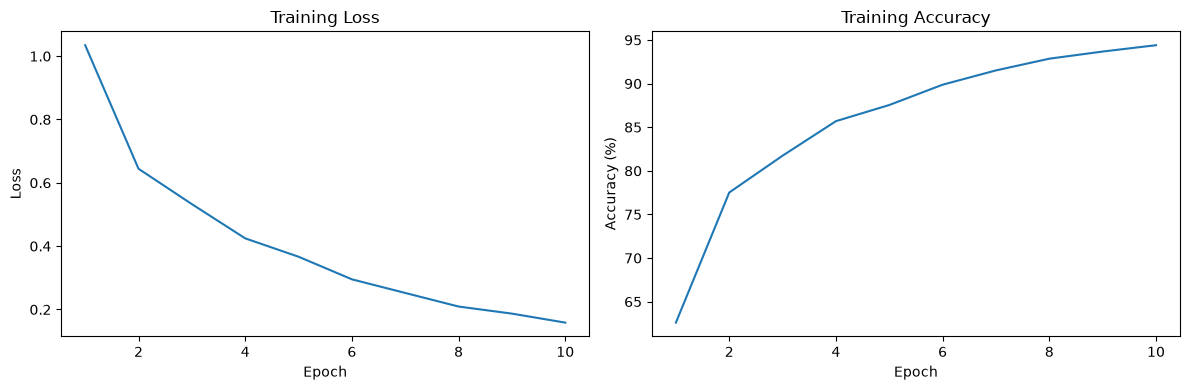

Saved training curves to training_curves.png


In [11]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, num_epochs + 1), train_losses)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(range(1, num_epochs + 1), train_accuracies)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()
print("Saved training curves to training_curves.png")

In [12]:
# --- Evaluation ---
def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_accuracy = 100 * correct / total
    print(f"\nTest Accuracy: {test_accuracy:.2f}%")

    print("\nPer-Class Accuracy:")
    for i, name in enumerate(class_names):
        class_mask = np.array(all_labels) == i
        if class_mask.sum() > 0:
            class_correct = np.array(all_predictions)[class_mask] == i
            class_acc = 100 * class_correct.sum() / class_mask.sum()
            print(f"  {name}: {class_acc:.1f}%")

    return test_accuracy, all_predictions, all_labels

In [13]:
# Run evaluation on test set
print("--- Evaluation ---")
test_accuracy, all_predictions, all_labels = evaluate_model(
    model, test_loader, device, class_names
)

--- Evaluation ---

Test Accuracy: 91.96%

Per-Class Accuracy:
  AnnualCrop: 90.0%
  Forest: 94.5%
  HerbaceousVegetation: 84.5%
  Highway: 87.4%
  Industrial: 95.9%
  Pasture: 96.5%
  PermanentCrop: 85.0%
  Residential: 98.5%
  River: 90.9%
  SeaLake: 97.5%


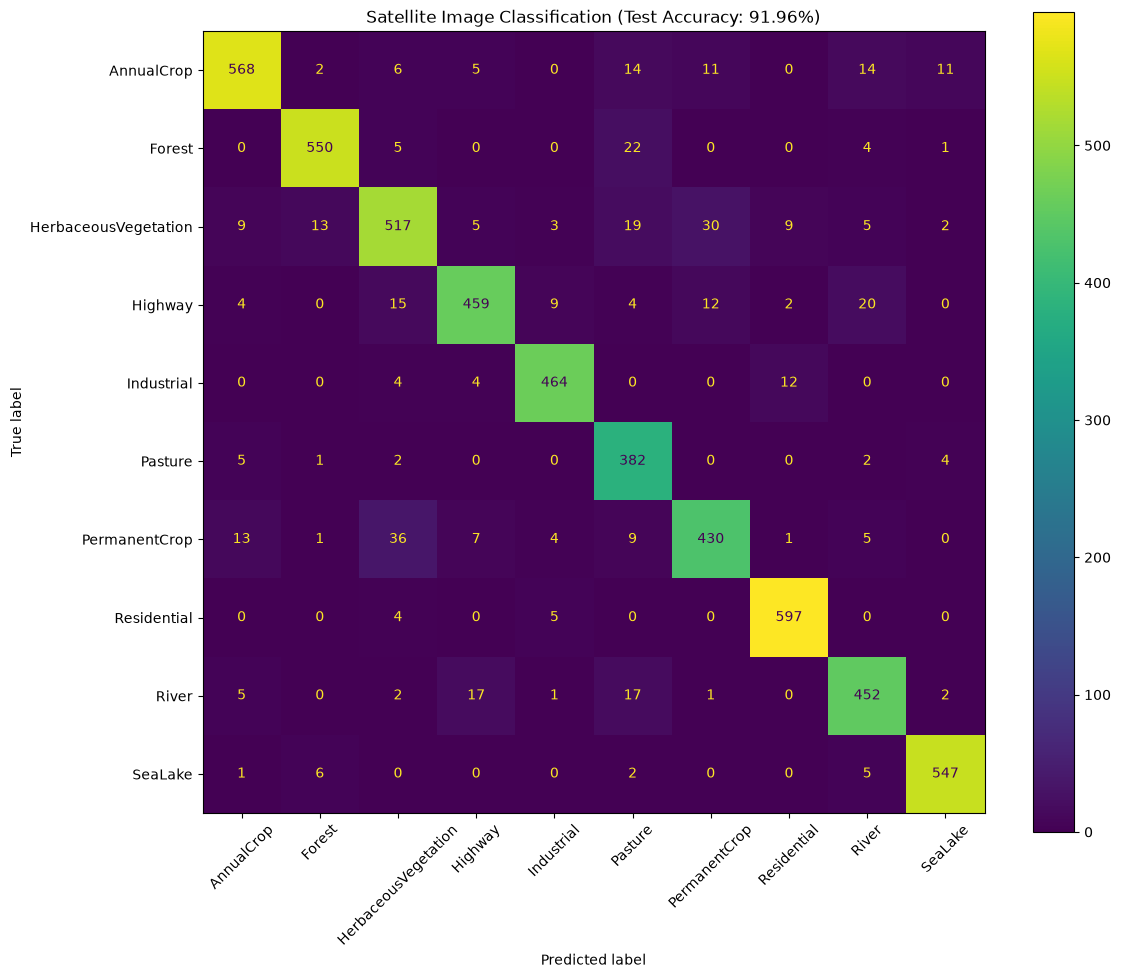

Saved confusion matrix to confusion_matrix.png


In [14]:
# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f"Satellite Image Classification (Test Accuracy: {test_accuracy:.2f}%)")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
print("Saved confusion matrix to confusion_matrix.png")